## Ejercicio 8, Simulated Annealing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# XOR 2 entradas
X_xor = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_xor = np.array([-1, 1, 1, -1])

In [ ]:
def sign_activation(h):
    y = np.where(h >= 0, 1, -1)
    return y

def tanh(x):
    return np.tanh(x)

def compute_error(y_hat, y):
    y=y.flatten()
    y_hat=y_hat.flatten()
    squared = np.square(y_hat - y)

    return np.sum(squared)

class SimulatedAnnealing:
    def __init__(self, input_size,hidden_size,output_size):
        self.b_1= np.random.normal(0,1,size=hidden_size) #bias
        self.b_2 = np.random.normal(0,1)

        self.weights = np.random.normal(0,1, size= [input_size,hidden_size]) #El numero de entradas es el largo de la fila
        self.weights2 = np.random.normal(0,1, size= [hidden_size,output_size])

    def train(self, X, y, learn_iterations, variance, temp, error_min, alpha):
        self.error_min = error_min



        error = self.error_min+1
        errors = []
        i=0
        while (i < learn_iterations and error>self.error_min ):

            y_hat=[]
            y_hat_p = []

            #Los valores de los pesos sampleados
            delta_w_p = np.random.normal(0,variance,size=self.weights.shape )
            delta_w2_p = np.random.normal(0,variance,size=self.weights2.shape)


            delta_b_1_p = np.random.normal(0,variance,size=self.b_1.shape)
            delta_b_2_p = np.random.normal(0,variance,size=1)

            w_p = delta_w_p + self.weights
            w2_p = delta_w2_p + self.weights2

            b_1_p = delta_b_1_p + self.b_1
            b_2_p = delta_b_2_p + self.b_2

            for index in range(len(y)):
                h = np.matmul(self.weights.T,X[index]) + self.b_1
                h= sign_activation(h)

                h = np.matmul(self.weights2.T,h) + self.b_2
                y_hat_i= sign_activation(h)



                h_p = np.matmul(w_p.T,X[index]) + b_1_p
                h_p= sign_activation(h_p)

                h_p = np.matmul(w2_p.T,h_p) + b_2_p
                y_hat_i_p= sign_activation(h_p)



                y_hat.append(y_hat_i)
                y_hat_p.append(y_hat_i_p)

            y_hat=np.array(y_hat).flatten()
            y_hat_p=np.array(y_hat_p).flatten()



            error = compute_error(y_hat=y_hat, y=y)


            error_p = compute_error(y_hat=y_hat_p, y=y)

            if(error>=error_min):

                #actualizacion de los pesos
                if(error_p <= error):
                    self.weights = w_p
                    self.weights2 = w2_p

                    self.b_1 = b_1_p
                    self.b_2 = b_2_p
                else:
                    proba= np.exp(-(error_p-error)/temp)
                    uniform = np.random.uniform(0,1)
                    if(proba>=uniform):
                        self.weights = w_p
                        self.weights2 = w2_p

                        self.b_1 = b_1_p
                        self.b_2 = b_2_p
            temp = alpha*temp

            errors.append(error)
            i+=1

        return errors

    def predict(self, X):
        prediction = []
        for index in range(len(X)):
            prediction.append(sign_activation(np.dot(self.weights,X[index]) + self.w_0 ))
        return np.array(prediction)

    def plot_decision_boundary(self, X, y):

        x1_vals = np.linspace(-2, 2, 100)
        x2_vals = -(self.weights[0] * x1_vals + self.w_0) / self.weights[1] #wT*x=0

        # Graficar los puntos de datos
        label_1=0
        label_min_1=0
        plt.figure(figsize=(6, 6))
        for i in range(len(X)):

            if y[i] == 1:
                if label_1==0:
                    plt.scatter(X[i][0],X[i][1], color='blue', label="y=1")
                    label_1=1
                else:
                    plt.scatter(X[i][0],X[i][1], color='blue')
            else:
                if label_min_1==0:
                    plt.scatter(X[i][0],X[i][1], color='red',label ="y=-1")
                    label_min_1=1
                else:
                    plt.scatter(X[i][0],X[i][1], color='red')


        # Graficar la frontera de decisión
        plt.plot(x1_vals, x2_vals, color='black', label=r'$w^T x = 0$')
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.grid(True)
        plt.title('Perceptron Decision Boundary')
        plt.legend()
        plt.show()

In [ ]:
modelo = SimulatedAnnealing(len(X_xor[0]),10,1)
error_evol = modelo.train(X=X_xor,y=y_xor,learn_iterations=10000, variance=1, temp=200, error_min=0.01, alpha=0.99)

Text(0, 0.5, 'Error')

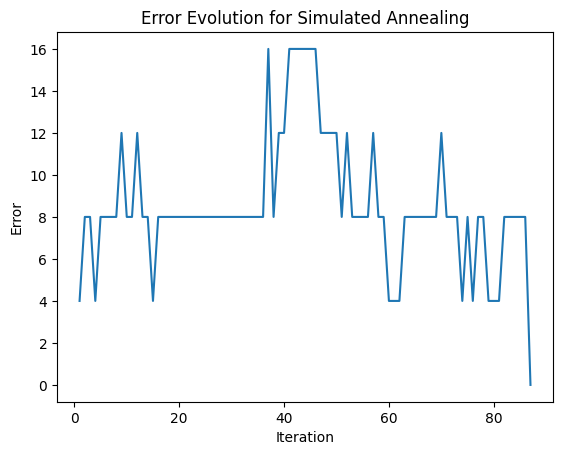

In [ ]:
plt.plot(range(1,len(error_evol)+1,1), error_evol)
plt.title("Error Evolution for Simulated Annealing")
plt.xlabel("Iteration")
plt.ylabel("Error")

# Kohonen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_n_patterns_circle_uniform(n_patterns):

    angles = np.random.uniform(0, 2 * np.pi, n_patterns)

    radii = np.sqrt(np.random.uniform(0, 1, n_patterns))

    # Cartesian coordinates
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)


    list_patterns=np.column_stack((x,y))
    return list_patterns

patterns = generate_n_patterns_circle_uniform(900)

In [ ]:
print(patterns.shape)

(900, 2)


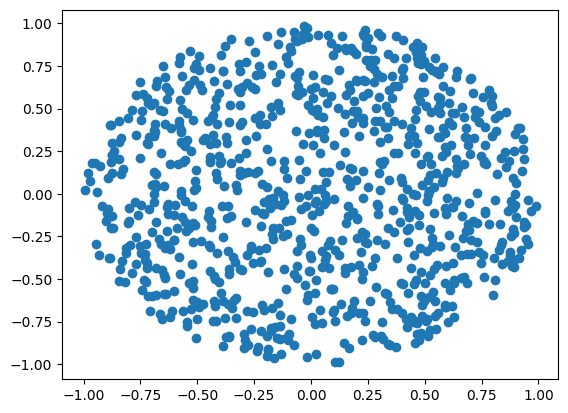

In [ ]:
plt.scatter(patterns[:,0],patterns[:,1])

In [ ]:
class Kohonen:
    def __init__(self, n_neurons):
        n_rows = int(np.sqrt(n_neurons))
        n_cols = n_rows

        x = np.linspace(0, n_cols-1, n_cols)  # x-coordinates
        y = np.linspace(0, n_rows-1, n_rows)  # y-coordinates
        positions = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)

        self.neuron_positions = positions
        weights = self._generate_n_patterns_circle_uniform(n_neurons)
        self.weight_positions = weights
        self.sigma = 100

    def train(self, data, eta, num_iterations):
        iteration = 0
        while iteration < num_iterations:
            np.random.shuffle(data)  # Mezcla los datos
            for data_point in data:
                data_copy = np.ones_like(self.weight_positions) * data_point
                distances = self._euclidean_distance(self.weight_positions, data_copy)
                index_min_dist = np.argmin(distances)

                # Actualiza los pesos
                for index in range(len(self.weight_positions)):
                    minimum_dist_position = self.neuron_positions[index_min_dist]
                    vecinity_value = self._vecinity(self.neuron_positions[index], minimum_dist_position)
                    self.weight_positions[index] += (eta * vecinity_value * (data_point - self.weight_positions[index]))

            # Decaimiento de sigma
            self.sigma = 100 * np.exp(-iteration / (num_iterations / 10))
            iteration += 1

    def _euclidean_distance(self, point1, point2):
        square_dif = (np.array(point1) - np.array(point2))**2
        if len(square_dif.shape) > 1:
            return np.sqrt(np.sum(square_dif, axis=1))
        else:
            return np.sqrt(np.sum(square_dif))

    def _vecinity(self, point1, point2):
        distance = self._euclidean_distance(point1, point2)
        num = -distance**2
        denomin = 2 * (self.sigma**2)
        return np.exp(num / denomin)

    def _generate_n_patterns_circle_uniform(self, n_patterns):
        angles = np.random.uniform(0, 2 * np.pi, n_patterns)
        radii = np.sqrt(np.random.uniform(0, 1, n_patterns))
        x = radii * np.cos(angles)
        y = radii * np.sin(angles)
        return np.column_stack((x, y))

    def show_plot_w(self,data):


        plt.scatter(self.weight_positions[:, 0], self.weight_positions[:, 1], label="Weights")
        plt.scatter(data[:, 0], data[:, 1], label="data")
        shapes_matrix = int(np.sqrt(len(self.weight_positions[:,0])))
        plt.plot(self.weight_positions[:,0].reshape(shapes_matrix,shapes_matrix),self.weight_positions[:,1].reshape(shapes_matrix,shapes_matrix))
        plt.plot(self.weight_positions[:,0].reshape(shapes_matrix,shapes_matrix).T,self.weight_positions[:,1].reshape(shapes_matrix,shapes_matrix).T)
        plt.legend()
        plt.title("Red de Kohonen. Distribución de pesos y de data")
        plt.show()


In [ ]:

patterns = generate_n_patterns_circle_uniform(4)
koho = Kohonen(4)
koho.train(data = patterns, eta=0.1, num_iterations=100)

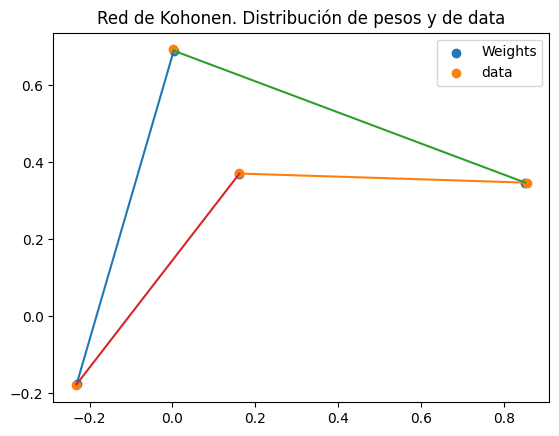

[[ 0.00321178  0.68992834]
 [ 0.85119941  0.34726674]
 [-0.23129572 -0.17686657]
 [ 0.16175875  0.37080417]]


In [ ]:
koho.show_plot_w(patterns)
print(koho.weight_positions)

In [ ]:
def generate_n_patterns_meshgrid(grid_size):
    grid_size=round(np.sqrt(grid_size))

    # Generate grid points
    x = np.linspace(0, 2, grid_size) -1
    y = np.linspace(0, 2, grid_size) -1
    grid_points = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)

    return grid_points

def generate_n_patterns_rotated(grid_size,angle):
    grid_size=round(np.sqrt(grid_size))

     # Generate grid points
    x = np.linspace(0, 2, grid_size) -1
    y = np.linspace(0, 2, grid_size) -1
    grid_points = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)

    # Define rotation angle (in degrees) and convert to radians
    angle_degrees = angle
    angle_radians = np.radians(angle_degrees)


    rotation_matrix = np.array([
        [np.cos(angle_radians), -np.sin(angle_radians)],
        [np.sin(angle_radians),  np.cos(angle_radians)]
    ])

    rotated_grid_points = grid_points @ rotation_matrix.T

    return rotated_grid_points


In [ ]:
patterns_mesh = generate_n_patterns_meshgrid(100)

koho_mesh = Kohonen(100)
koho_mesh.train(data = patterns_mesh, eta=0.1, num_iterations=100)

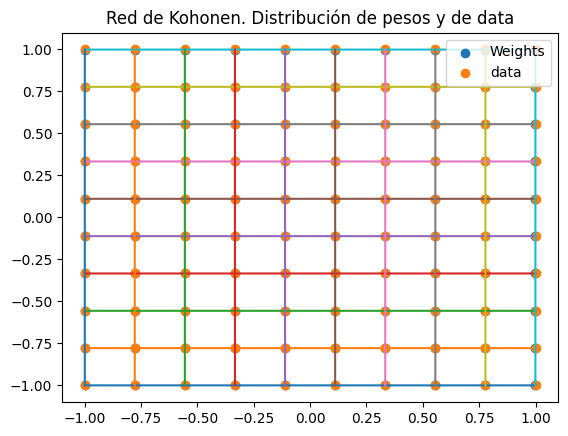

In [ ]:
koho_mesh.show_plot_w(patterns_mesh)

In [ ]:
patterns_mesh_rotated = generate_n_patterns_rotated(100,45)

koho_mesh_rotated = Kohonen(100)
koho_mesh_rotated.train(data = patterns_mesh_rotated, eta=0.1, num_iterations=100)

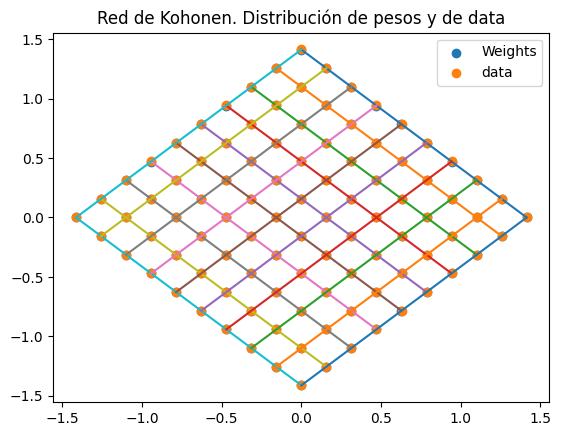

In [ ]:
koho_mesh_rotated.show_plot_w(patterns_mesh_rotated)

In [ ]:
def sample_triangle(num_samples):
    samples = []
    for _ in range(num_samples):
        u, v = np.random.rand(2)
        if u + v > 1:
            u, v = 1 - u, 1 - v
        x = (1 - u - v) * (-0.5) + u * 0.5 + v * 0
        y = (1 - u - v) * 0 + u * 0 + v * 0.5
        samples.append((x, y))
    return np.array(samples)

# Generate samples
num_samples = 400
samples_triangle = sample_triangle(num_samples)


In [ ]:
koho_triangle = Kohonen(400)
koho_triangle.train(data = samples_triangle, eta=0.1, num_iterations=100)

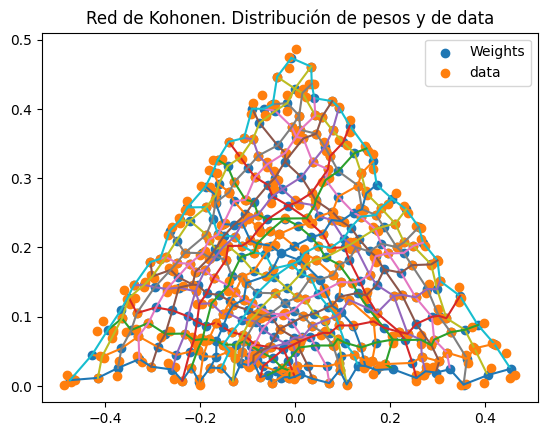

In [ ]:
koho_triangle.show_plot_w(samples_triangle)

# Problema del viajante

In [ ]:
class Kohonen_viajante:
    def __init__(self, n_neurons):
        n_rows = int(np.sqrt(n_neurons))
        n_cols = n_rows

        #dibujo un circulo
        angulos = np.linspace(0, 2 * np.pi, n_neurons, endpoint=False)
        positions = np.column_stack((np.cos(angulos), np.sin(angulos)))


        self.neuron_positions = positions
        weights = self._generate_n_patterns_circle_uniform(n_neurons)
        self.weight_positions = weights
        self.sigma = 100

    def train(self, data, eta, num_iterations):
        iteration = 0
        while iteration < num_iterations:
            np.random.shuffle(data)  # Mezcla los datos
            for data_point in data:
                data_copy = np.ones_like(self.weight_positions) * data_point
                distances = self._euclidean_distance(self.weight_positions, data_copy)
                index_min_dist = np.argmin(distances)

                # Actualiza los pesos
                for index in range(len(self.weight_positions)):
                    minimum_dist_position = self.neuron_positions[index_min_dist]
                    vecinity_value = self._vecinity(self.neuron_positions[index], minimum_dist_position)
                    self.weight_positions[index] += (eta * vecinity_value * (data_point - self.weight_positions[index]))

            # Decaimiento de sigma
            self.sigma = 100 * np.exp(-iteration / (num_iterations / 10))
            iteration += 1

    def _euclidean_distance(self, point1, point2):
        square_dif = (np.array(point1) - np.array(point2))**2
        if len(square_dif.shape) > 1:
            return np.sqrt(np.sum(square_dif, axis=1))
        else:
            return np.sqrt(np.sum(square_dif))

    def _vecinity(self, point1, point2):
        distance = self._euclidean_distance(point1, point2)
        num = -distance**2
        denomin = 2 * (self.sigma**2)
        return np.exp(num / denomin)

    def _generate_n_patterns_circle_uniform(self, n_patterns):
        angles = np.random.uniform(0, 2 * np.pi, n_patterns)
        radii = np.sqrt(np.random.uniform(0, 1, n_patterns))
        x = radii * np.cos(angles)
        y = radii * np.sin(angles)
        return np.column_stack((x, y))

    def show_plot_w(self,data):


        plt.scatter(self.weight_positions[:, 0], self.weight_positions[:, 1])
        plt.scatter(data[:, 0], data[:, 1], label="Cities")
        plt.plot(self.weight_positions[:,0],self.weight_positions[:,1], label="Path")

        plt.legend()
        plt.title("Red de Kohonen. Problema del viajante.")
        plt.show()


In [ ]:
num_cities = 200
samples_traveler = np.random.uniform(0,1, size=[num_cities, 2])
koho_viajante = Kohonen_viajante(400)
koho_viajante.train(data = samples_traveler, eta=0.1, num_iterations=100)

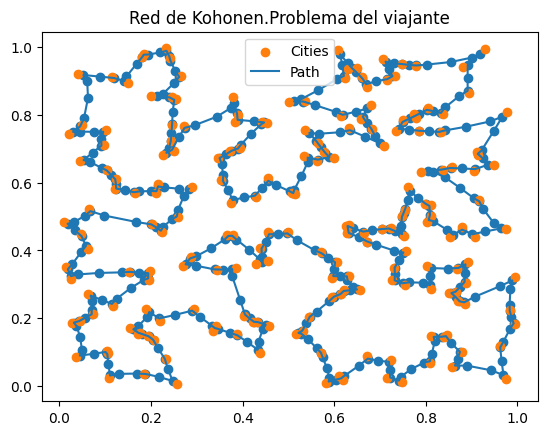

In [ ]:
koho_viajante.show_plot_w(samples_traveler)